<h1 dir="rtl" style="font-family: Vazir; width: 85%;">تمرین شماره ۱: درس بازیابی هوشمند اطلاعات - دانشگاه تهران، پائیز ۱۴۰۳</h1>

<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 18px;">
نام: عرفان شهابی
<br/>


<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 18px;">
مدل ها در فایل retrieval_models.py نوشته شده است
<br/>
Precision@10 در فایل evaluation.py تعریف شده است.

<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
سوالات خودتان را می‌توانید از طریق ایمیل
<code>miladmohammadi@ut.ac.ir</code>
 از طراح تمرین ? بپرسید.

<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 18px; color: red; font-weight: bold;">
قوانین و توضیحاتی آخر فایل تمرین حتما به دقت مطالعه شود.
</div>

In [35]:
!pip install nltk
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn

In [1]:
import document_processing as dp
import inverted_index as ii
import query_processing as qp
import evaluation as ev

In [2]:
# Load the autoreload extension
%load_ext autoreload

# Set autoreload to Mode 1: Reload modules only when explicitly imported
%autoreload 1

# Mark specific modules for autoreloading
%aimport retrieval_models


import retrieval_models as rm

In [4]:
# Ensure NLTK data is downloaded
import nltk
import numpy as np
import pandas as pd
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
print(nltk.data.path)

['/Users/erfanshahabi/nltk_data', '/Library/Frameworks/Python.framework/Versions/3.12/nltk_data', '/Library/Frameworks/Python.framework/Versions/3.12/share/nltk_data', '/Library/Frameworks/Python.framework/Versions/3.12/lib/nltk_data', '/usr/share/nltk_data', '/usr/local/share/nltk_data', '/usr/lib/nltk_data', '/usr/local/lib/nltk_data']


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/erfanshahabi/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/erfanshahabi/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/erfanshahabi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# **سوال اول:**

## Loading the dataset 1

In [5]:
# Paths to data files
corpus_file = '/Users/erfanshahabi/Desktop/uni/IR/IIR-CA1/Code/data/IIR-CA1-data/LA.xml' #LA.xml
query_file = '/Users/erfanshahabi/Desktop/uni/IR/IIR-CA1/Code/data/IIR-CA1-data/topics.xml' #topics.xml
relevance_file = '/Users/erfanshahabi/Desktop/uni/IR/IIR-CA1/Code/data/IIR-CA1-data/jud-la.txt' #jud-la.txt
stopwords_file = '/Users/erfanshahabi/Desktop/uni/IR/IIR-CA1/Code/data/IIR-CA1-data/stops_en.txt' #stops_en.txt

In [6]:
# 1. Data Loading and Preprocessing
dataset_type = 'type2'
# Load stopwords
stop_words = dp.load_stopwords(stopwords_file)

print("Loading and preprocessing documents...")
documents = dp.load_documents(corpus_file, dataset_type=dataset_type)
for idx, doc in enumerate(documents):
    doc.preprocess(stop_words=stop_words)
    if (idx + 1) % 100 == 0 or idx == len(documents) - 1:
        print(f"Processed {idx+1}/{len(documents)} documents")

print("Building inverted index...")
inverted_index = ii.InvertedIndex()
inverted_index.build_index(documents)

print("Loading and preprocessing queries...")
queries = qp.load_queries(query_file, dataset_type=dataset_type)
for query in queries:
    query.preprocess(stop_words=stop_words)

print("Loading relevance judgments...")
relevance_judgments = ev.load_relevance_judgments(relevance_file)

Loading and preprocessing documents...
Processed 100/113005 documents
Processed 200/113005 documents
Processed 300/113005 documents
Processed 400/113005 documents
Processed 500/113005 documents
Processed 600/113005 documents
Processed 700/113005 documents
Processed 800/113005 documents
Processed 900/113005 documents
Processed 1000/113005 documents
Processed 1100/113005 documents
Processed 1200/113005 documents
Processed 1300/113005 documents
Processed 1400/113005 documents
Processed 1500/113005 documents
Processed 1600/113005 documents
Processed 1700/113005 documents
Processed 1800/113005 documents
Processed 1900/113005 documents
Processed 2000/113005 documents
Processed 2100/113005 documents
Processed 2200/113005 documents
Processed 2300/113005 documents
Processed 2400/113005 documents
Processed 2500/113005 documents
Processed 2600/113005 documents
Processed 2700/113005 documents
Processed 2800/113005 documents
Processed 2900/113005 documents
Processed 3000/113005 documents
Processed 

## Example

In [7]:
print("\nSample run with BM25 (k=1.5, b=0.75)")
params = {'k': 1.5, 'b': 0.75}
evaluation_results = ev.evaluate_scoring_method(inverted_index,rm.bm25_score, queries, relevance_judgments, params=params)
print(evaluation_results)
print(f"MAP for BM25 (k={1.5}, b={0.75}): {evaluation_results['MAP']}")


Sample run with BM25 (k=1.5, b=0.75)
{'MAP': 0.3672, 'Precision@10': 0.338, 'Recall@10': 0.3102, 'nDCG@5': 0.5081}
MAP for BM25 (k=1.5, b=0.75): 0.3672


# **به دست آوردن مقادیر بهینه k , b**

In [8]:
import numpy as np

#with long steps
k_values_large = np.arange(1.0, 2.1, 0.5)  
b_values_large = np.arange(0.0, 1.1, 0.5)  
best_map_large = 0
best_params_large = (0, 0)

for k in k_values_large:
    for b in b_values_large:
        print(f"Evaluating BM25 with k={k}, b={b}")
        params = {'k': k, 'b': b}
        evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.bm25_score, queries, relevance_judgments, params=params)
        current_map = evaluation_results['MAP']
        print(f"MAP for BM25 (k={k}, b={b}): {current_map}")
        
        if current_map > best_map_large:
            best_map_large = current_map
            best_params_large = (k, b)

print(f"\nBest MAP with large steps: {best_map_large} with parameters k={best_params_large[0]}, b={best_params_large[1]}")

#with small steps
k_start, b_start = best_params_large

k_values_small = np.arange(k_start - 0.2, k_start + 0.3, 0.05)  
b_values_small = np.arange(b_start - 0.2, b_start + 0.3, 0.05)  

best_map_small = 0
best_params_small = (0, 0)


for k in k_values_small:
    for b in b_values_small:
        print(f"Evaluating BM25 with k={k}, b={b}")
        params = {'k': k, 'b': b}
        evaluation_results = ev.evaluate_scoring_method(
            inverted_index,
            rm.bm25_score,
            queries,
            relevance_judgments,
            params=params
        )
        current_map = evaluation_results['MAP']
        print(f"MAP for BM25 (k={k}, b={b}): {current_map}")
        
        if current_map > best_map_small:
            best_map_small = current_map
            best_params_small = (k, b)

print(f"\nBest MAP with small steps: {best_map_small} with parameters k={best_params_small[0]}, b={best_params_small[1]}")


Evaluating BM25 with k=1.0, b=0.0
MAP for BM25 (k=1.0, b=0.0): 0.3654
Evaluating BM25 with k=1.0, b=0.5
MAP for BM25 (k=1.0, b=0.5): 0.395
Evaluating BM25 with k=1.0, b=1.0
MAP for BM25 (k=1.0, b=1.0): 0.3477
Evaluating BM25 with k=1.5, b=0.0
MAP for BM25 (k=1.5, b=0.0): 0.3533
Evaluating BM25 with k=1.5, b=0.5
MAP for BM25 (k=1.5, b=0.5): 0.3933
Evaluating BM25 with k=1.5, b=1.0
MAP for BM25 (k=1.5, b=1.0): 0.3361
Evaluating BM25 with k=2.0, b=0.0
MAP for BM25 (k=2.0, b=0.0): 0.3434
Evaluating BM25 with k=2.0, b=0.5
MAP for BM25 (k=2.0, b=0.5): 0.3881
Evaluating BM25 with k=2.0, b=1.0
MAP for BM25 (k=2.0, b=1.0): 0.323

Best MAP with large steps: 0.395 with parameters k=1.0, b=0.5
Evaluating BM25 with k=0.8, b=0.3
MAP for BM25 (k=0.8, b=0.3): 0.3954
Evaluating BM25 with k=0.8, b=0.35
MAP for BM25 (k=0.8, b=0.35): 0.3965
Evaluating BM25 with k=0.8, b=0.39999999999999997
MAP for BM25 (k=0.8, b=0.39999999999999997): 0.3971
Evaluating BM25 with k=0.8, b=0.44999999999999996
MAP for BM25 (k

<div style="direction: rtl; text-align: right;">
    ابتدا آرایه ای از مقادیر k و b با کام های بزرگ ساخته می شود. k از ۱.۰ تا ۲.۰ با گام ۰.۵ و b از ۰.۰ تا ۱.۰ با گام ۰.۵ تولید می شود.
    <br><br>
    برای هر ترکیب از این مقادیر b و k، تابع ارزیابی (ev.evaluate_scoring_method) با پارامترهای مشخص شده اجرا می‌شود. این تابع،مدل BM25 را برای هر ترکیب از k,b بر روی مجموعه‌ داده‌ها اعمال می‌کند و سپس MAP را محاسبه می‌کند.
    <br><br>
    پس از هر ارزیابی، MAP محاسبه‌شده با بهترین MAP قبلی مقایسه می‌شود. اگر MAP فعلی بهتر باشد، مقادیر k و b به عنوان بهترین پارامترها ذخیره می‌شوند.
    <br><br>
    پس از یافتن بهترین پارامترهای اولیه در مرحله اول، جستجوی دقیق‌تری در اطراف آن‌ها انجام می‌شود. آرایه‌ای از مقادیر k و b با گام‌های کوچک‌تر (0.05) و دامنه‌ای کوچک‌تر (±0.01 اطراف مقادیر اولیه) ساخته می‌شود.
    <br><br>
    مانند مرحله اول، هر ترکیب از این مقادیر دقیق‌تر k و b دوباره ارزیابی می‌شود تا بهترین MAP ممکن برای این محدوده‌ها پیدا شود. مشابه مرحله قبل، بهترین مقادیر k و b که بالاترین MAP را ارائه می‌دهند، به عنوان پارامترهای نهایی انتخاب می‌شوند. در پایان هر مرحله، MAP و بهترین مقادیر k و b چاپ می‌شوند. پس از مرحله دوم (با گام‌های کوچک‌تر)، بهترین MAP نهایی و پارامترهای بهینه نهایی k و b ارائه می‌شود.
    <br><br>
    ۱. پارامتر k:
    <br><br>
    این پارامتر عموماً relevance بین سند و کوئری را کنترل می‌کند.
    <br><br>
    k کوچک‌تر: باعث می‌شود که مدل به تطابق دقیق‌تر بین کلمات کوئری و سند حساس‌تر باشد و برای هر بار مشاهده کلمه، مقدار بیشتری از امتیاز به سند تعلق گیرد. این حالت برای کوئری‌هایی با کلمات مهم‌تر مناسب است.
    <br><br>
    k بزرگ‌تر: باعث می‌شود که حتی اگر یک کلمه چندین بار در سند ظاهر شود، تأثیر آن به‌سرعت کاهش یابد. این موضوع برای کوئری‌های طولانی یا سندهایی با محتوای متنوع مفید است.
    <br><br>
    ۲. پارامتر b:
    این پارامتر میزان تأثیر طول سند (document length) را بر روی امتیازدهی کنترل می‌کند. به‌عبارت دیگر، مشخص می‌کند که تا چه اندازه سندهای بلندتر باید پاداش بگیرند یا جریمه شوند.
    <br><br>
    b = ۰: نشان می‌دهد که طول سند هیچ تأثیری بر امتیازدهی ندارد و مدل تنها به تناسب بین کوئری و سند توجه می‌کند.
    <br><br>
    b = ۱: یعنی مدل به طور کامل اثر طول سند را در نظر می‌گیرد. سندهای بلندتر ممکن است جریمه شوند، چراکه محتوای زیادی دارند و ممکن است کلمات غیرمرتبط بیشتری داشته باشند. سندهای کوتاه‌تر در این حالت می‌توانند در اولویت قرار گیرند.

<div>



# **سوال اول قسمت ب تست روش های پیشنهادی:**

In [15]:
evaluation_results_dict = {}
params_dict = {}
import numpy as np
#model 1
evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.model1, queries, relevance_judgments)
evaluation_results_dict['model1'] = evaluation_results
print("evaluation results for model1:",evaluation_results)
print(f"MAP for model1: {evaluation_results['MAP']}")

#model 2
#with long steps
k_values_large = np.arange(0.0, 1.1, 0.5)  
best_map_large = 0
best_d_large = 0

for d in k_values_large:
    print(f"Evaluating model2 with k={k}")
    params = {'k': k}
    evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.model2,  queries, relevance_judgments, params=params)
    current_map = evaluation_results['MAP']
    print(f"MAP for model2 (k={k}): {current_map}")

    if current_map > best_map_large:
        best_map_large = current_map
        best_k_large = k

print(f"\nBest MAP with large steps: {best_map_large} with k={best_k_large}")

#with small steps
k_start = best_k_large

k_values_small = np.arange(k_start - 0.2, k_start + 0.3, 0.05) 

best_map_small = 0
best_k_small = 0

for d in k_values_small:
    print(f"Evaluating model2 with k={k}")
    params = {'k': k}
    evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.model2, queries, relevance_judgments, params=params)
    current_map = evaluation_results['MAP']
    print(f"MAP for model2 (k={k}): {current_map}")

    if current_map > best_map_small:
        best_map_small = current_map
        best_k_small = k

print(f"\nBest MAP with small steps: {best_map_small} with k={best_k_small}")

# Store only the best results for model9 in the dictionary
params = {'k': best_k_small}
evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.model2, queries, relevance_judgments, params=params)
evaluation_results_dict['model2_final'] = evaluation_results 
params_dict['model2_k'] = best_k_small
print("evaluation results for model2:",evaluation_results)
print(f"MAP for model2 (k={best_k_small}): {evaluation_results['MAP']}")

#model 3
#with long steps
k_values_large = np.arange(0.0, 1.1, 0.5)  
best_map_large = 0
best_d_large = 0

for k in k_values_large:
    print(f"Evaluating model3 with k={k}")
    params = {'k': k}
    evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.model3,  queries, relevance_judgments, params=params)
    current_map = evaluation_results['MAP']
    print(f"MAP for model3 (k={k}): {current_map}")

    if current_map > best_map_large:
        best_map_large = current_map
        best_k_large = k

print(f"\nBest MAP with large steps: {best_map_large} with k={best_k_large}")

#with small steps
k_start = best_k_large

k_values_small = np.arange(k_start - 0.2, k_start + 0.3, 0.05) 

best_map_small = 0
best_k_small = 0

for d in k_values_small:
    print(f"Evaluating model3 with k={k}")
    params = {'k': k}
    evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.model3, queries, relevance_judgments, params=params)
    current_map = evaluation_results['MAP']
    print(f"MAP for model3 (k={k}): {current_map}")

    if current_map > best_map_small:
        best_map_small = current_map
        best_k_small = k

print(f"\nBest MAP with small steps: {best_map_small} with k={best_k_small}")

# Store only the best results for model9 in the dictionary
params = {'k': best_k_small}
evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.model3, queries, relevance_judgments, params=params)
evaluation_results_dict['model3_final'] = evaluation_results 
params_dict['model3_k'] = best_k_small
print("evaluation results for model3:",evaluation_results)
print(f"MAP for model3 (k={best_k_small}): {evaluation_results['MAP']}")


#model 4
params = {}
evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.model4, queries, relevance_judgments, params=params)
evaluation_results_dict['model4'] = evaluation_results
print("evaluation results for model4:",evaluation_results)
print(f"MAP for model4: {evaluation_results['MAP']}")

#model 5


# With large steps
k_values_large = np.arange(0.0, 2.0, 0.5)  
b_values_large = np.arange(0.0, 1.1, 0.5)  
d = 0.5  

best_map_large = 0
best_k_large = 0
best_b_large = 0

for k in k_values_large:
    for b in b_values_large:
        print(f"Evaluating model5 with k={k}, b={b}, d={d}")
        params = {'k': k, 'b': b, 'd': d}
        evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.model5, queries, relevance_judgments, params=params)
        current_map = evaluation_results['MAP']
        print(f"MAP for model5 (k={k}, b={b}, d={d}): {current_map}")

        if current_map > best_map_large:
            best_map_large = current_map
            best_k_large = k
            best_b_large = b

print(f"\nBest MAP with large steps: {best_map_large} with k={best_k_large}, b={best_b_large}, d={d}")

# With small steps
k_start = best_k_large
b_start = best_b_large

k_values_small = np.arange(k_start - 0.2, k_start + 0.3, 0.1)  
b_values_small = np.arange(b_start - 0.2, b_start + 0.3, 0.1)  

best_map_small = 0
best_k_small = 0
best_b_small = 0

for k in k_values_small:
    for b in b_values_small:
        print(f"Evaluating model5 with k={k}, b={b}, d={d}")
        params = {'k': k, 'b': b, 'd': d}
        evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.model5, queries, relevance_judgments, params=params)
        current_map = evaluation_results['MAP']
        print(f"MAP for model5 (k={k}, b={b}, d={d}): {current_map}")

        if current_map > best_map_small:
            best_map_small = current_map
            best_k_small = k
            best_b_small = b

print(f"\nBest MAP with small steps: {best_map_small} with k={best_k_small}, b={best_b_small}, d={d}")

params = {'k': best_k_small, 'b': best_b_small, 'd': d}
evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.model5, queries, relevance_judgments, params=params)
evaluation_results_dict['model5_final'] = evaluation_results
params_dict['model5_k'] = best_k_small
params_dict['model5_b'] = best_b_small
params_dict['model5_d'] = d
print("evaluation results for model5:", evaluation_results)
print(f"MAP for model5 (k={best_k_small}, b={best_b_small}, d={d}): {evaluation_results['MAP']}")


#model 6
N = float(len(inverted_index.doc_lengths)) 
params = {'N': N} 
evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.model6, queries, relevance_judgments, params=params)
evaluation_results_dict['model6'] = evaluation_results
print("evaluation results for model6:",evaluation_results)
print(f"MAP for model6: {evaluation_results['MAP']}")

#model 7
# With large steps 
k_values_large = np.arange(0.0, 2.0, 0.5)  
b_values_large = np.arange(0.0, 1.1, 0.5)  

best_map_large = 0
best_k_large = 0
best_b_large = 0

for k in k_values_large:
    for b in b_values_large:
        print(f"Evaluating model7 with k={k}, b={b}")
        params = {'k': k, 'b': b}
        evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.model7, queries, relevance_judgments, params=params)
        current_map = evaluation_results['MAP']
        print(f"MAP for model7 (k={k}, b={b}): {current_map}")

        if current_map > best_map_large:
            best_map_large = current_map
            best_k_large = k
            best_b_large = b

print(f"\nBest MAP with large steps: {best_map_large} with k={best_k_large}, b={best_b_large}")
# With small steps 
k_start = best_k_large
b_start = best_b_large

k_values_small = np.arange(k_start - 0.2, k_start + 0.3, 0.05) 
b_values_small = np.arange(b_start - 0.2, b_start + 0.3, 0.05)  

best_map_small = 0
best_k_small = 0
best_b_small = 0

for k in k_values_small:
    for b in b_values_small:
        print(f"Evaluating model7 with k={k}, b={b}")
        params = {'k': k, 'b': b}
        evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.model7, queries, relevance_judgments, params=params)
        current_map = evaluation_results['MAP']
        print(f"MAP for model7 (k={k}, b={b}): {current_map}")

        if current_map > best_map_small:
            best_map_small = current_map
            best_k_small = k
            best_b_small = b

print(f"\nBest MAP with small steps: {best_map_small} with k={best_k_small}, b={best_b_small}")

params = {'k': best_k_small, 'b': best_b_small}
evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.model7, queries, relevance_judgments, params=params)
evaluation_results_dict['model7_final'] = evaluation_results
params_dict['model7_k'] = best_k_small
params_dict['model7_b'] = best_b_small
print("evaluation results for model7:", evaluation_results)
print(f"MAP for model7 (k={best_k_small}, b={best_b_small}): {evaluation_results['MAP']}")

#model 8
# With large steps 
k_values_large = np.arange(0.0, 2.0, 0.5)  
b_values_large = np.arange(0.0, 1.1, 0.5)  

best_map_large = 0
best_k_large = 0
best_b_large = 0

for k in k_values_large:
    for b in b_values_large:
        print(f"Evaluating model8 with k={k}, b={b}")
        params = {'k': k, 'b': b}
        evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.model8, queries, relevance_judgments, params=params)
        current_map = evaluation_results['MAP']
        print(f"MAP for model8 (k={k}, b={b}): {current_map}")

        if current_map > best_map_large:
            best_map_large = current_map
            best_k_large = k
            best_b_large = b

print(f"\nBest MAP with large steps: {best_map_large} with k={best_k_large}, b={best_b_large}")
# With small steps 
k_start = best_k_large
b_start = best_b_large

k_values_small = np.arange(k_start - 0.2, k_start + 0.3, 0.05) 
b_values_small = np.arange(b_start - 0.2, b_start + 0.3, 0.05)  

best_map_small = 0
best_k_small = 0
best_b_small = 0

for k in k_values_small:
    for b in b_values_small:
        print(f"Evaluating model8 with k={k}, b={b}")
        params = {'k': k, 'b': b}
        evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.model8, queries, relevance_judgments, params=params)
        current_map = evaluation_results['MAP']
        print(f"MAP for model8 (k={k}, b={b}): {current_map}")

        if current_map > best_map_small:
            best_map_small = current_map
            best_k_small = k
            best_b_small = b

print(f"\nBest MAP with small steps: {best_map_small} with k={best_k_small}, b={best_b_small}")

params = {'k': best_k_small, 'b': best_b_small}
evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.model8, queries, relevance_judgments, params=params)
evaluation_results_dict['model8_final'] = evaluation_results
params_dict['model8_k'] = best_k_small
params_dict['model8_b'] = best_b_small
print("evaluation results for model7:", evaluation_results)
print(f"MAP for model8 (k={best_k_small}, b={best_b_small}): {evaluation_results['MAP']}")

#model 9
#with long steps
k_values_large = np.arange(0.0, 2.0, 0.5)  
b_values_large = np.arange(0.0, 1.1, 0.5)  
d_values_large = np.arange(0.0, 1.1, 0.5)  

best_map_large = 0
best_k_large = 0
best_b_large = 0
best_d_large = 0

for k in k_values_large:
    for b in b_values_large:
        for d in d_values_large:
            print(f"Evaluating model9 with k={k}, b={b}, d={d}")
            params = {'k': k, 'b': b, 'd': d}
            evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.model9, queries, relevance_judgments, params=params)
            current_map = evaluation_results['MAP']
            print(f"MAP for model9 (k={k}, b={b}, d={d}): {current_map}")

            if current_map > best_map_large:
                best_map_large = current_map
                best_k_large = k
                best_b_large = b
                best_d_large = d

print(f"\nBest MAP with large steps: {best_map_large} with k={best_k_large}, b={best_b_large}, d={best_d_large}")
# With small steps
k_start = best_k_large
b_start = best_b_large
d_start = best_d_large

k_values_small = np.arange(k_start - 0.2, k_start + 0.3, 0.1)  
b_values_small = np.arange(b_start - 0.2, b_start + 0.3, 0.1)  
d_values_small = np.arange(d_start - 0.2, d_start + 0.3, 0.1)  

best_map_small = 0
best_k_small = 0
best_b_small = 0
best_d_small = 0

for k in k_values_small:
    for b in b_values_small:
        for d in d_values_small:
            print(f"Evaluating model9 with k={k}, b={b}, d={d}")
            params = {'k': k, 'b': b, 'd': d}
            evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.model9, queries, relevance_judgments, params=params)
            current_map = evaluation_results['MAP']
            print(f"MAP for model9 (k={k}, b={b}, d={d}): {current_map}")

            if current_map > best_map_small:
                best_map_small = current_map
                best_k_small = k
                best_b_small = b
                best_d_small = d

print(f"\nBest MAP with small steps: {best_map_small} with k={best_k_small}, b={best_b_small}, d={best_d_small}")

params = {'k': best_k_small, 'b': best_b_small, 'd': best_d_small}
evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.model9, queries, relevance_judgments, params=params)
evaluation_results_dict['model9_final'] = evaluation_results
params_dict['model9_k'] = best_k_small
params_dict['model9_b'] = best_b_small
params_dict['model9_d'] = best_d_small
print("evaluation results for model9:", evaluation_results)
print(f"MAP for model5 (k={best_k_small}, b={best_b_small}, d={best_d_small}): {evaluation_results['MAP']}")

#model 10
#مدل پیشنهادی
# With large steps 
alpha_values_large = np.arange(0.0, 1.1, 0.2)  

best_map_large = 0
best_alpha_large = 0

for alpha in alpha_values_large:
    print(f"Evaluating model10 with alpha={alpha}")
    params = {'alpha': alpha}
    evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.model10, queries, relevance_judgments, params=params)
    current_map = evaluation_results['MAP']
    print(f"MAP for model10 (alpha={alpha}): {current_map}")

    if current_map > best_map_large:
        best_map_large = current_map
        best_alpha_large = alpha

print(f"\nBest MAP with large steps: {best_map_large} with alpha={best_alpha_large}")
# With small steps 
alpha_start = best_alpha_large

alpha_values_small = np.arange(alpha_start - 0.1, alpha_start + 0.15, 0.02)

best_map_small = 0
best_alpha_small = 0

for alpha in alpha_values_small:
    print(f"Evaluating model10 with alpha={alpha}")
    params = {'alpha': alpha}
    evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.model10, queries, relevance_judgments, params=params)
    current_map = evaluation_results['MAP']
    print(f"MAP for model10 (alpha={alpha}): {current_map}")

    if current_map > best_map_small:
        best_map_small = current_map
        best_alpha_small = alpha

print(f"\nBest MAP with small steps: {best_map_small} with alpha={best_alpha_small}")
params = {'alpha': best_alpha_small}
evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.model10, queries, relevance_judgments, params=params)
evaluation_results_dict['model10_final'] = evaluation_results
params_dict['model10_alpha'] = best_alpha_small
print("evaluation results for model10:", evaluation_results)
print(f"MAP for model10 (alpha={best_alpha_small}): {evaluation_results['MAP']}")


for model, results in evaluation_results_dict.items():
    results_line = ', '.join([f"{key}: {value}" for key, value in results.items()])
    print(f"{model}: {results_line}")




evaluation results for model1: {'MAP': 0.2192, 'Precision@10': 0.183, 'Recall@10': 0.2021, 'nDCG@5': 0.2172}
MAP for model1: 0.2192
Evaluating model2 with k=0.5
MAP for model2 (k=0.5): 0.3211
Evaluating model2 with k=0.5
MAP for model2 (k=0.5): 0.3211
Evaluating model2 with k=0.5
MAP for model2 (k=0.5): 0.3211

Best MAP with large steps: 0.3211 with k=0.5
Evaluating model2 with k=0.5
MAP for model2 (k=0.5): 0.3211
Evaluating model2 with k=0.5
MAP for model2 (k=0.5): 0.3211
Evaluating model2 with k=0.5
MAP for model2 (k=0.5): 0.3211
Evaluating model2 with k=0.5
MAP for model2 (k=0.5): 0.3211
Evaluating model2 with k=0.5
MAP for model2 (k=0.5): 0.3211
Evaluating model2 with k=0.5
MAP for model2 (k=0.5): 0.3211
Evaluating model2 with k=0.5
MAP for model2 (k=0.5): 0.3211
Evaluating model2 with k=0.5
MAP for model2 (k=0.5): 0.3211
Evaluating model2 with k=0.5
MAP for model2 (k=0.5): 0.3211
Evaluating model2 with k=0.5
MAP for model2 (k=0.5): 0.3211

Best MAP with small steps: 0.3211 with k=

In [17]:
for model, results in evaluation_results_dict.items():
    results_line = ', '.join([f"{key}: {value}" for key, value in results.items()])
    print(f"{model}: {results_line}")
for model, params in params_dict.items():
    print(f"{model}: {params}")

model1: MAP: 0.2192, Precision@10: 0.183, Recall@10: 0.2021, nDCG@5: 0.2172
model2_final: MAP: 0.3211, Precision@10: 0.329, Recall@10: 0.2831, nDCG@5: 0.4617
model3_final: MAP: 0.3477, Precision@10: 0.322, Recall@10: 0.3135, nDCG@5: 0.4647
model4: MAP: 0.1946, Precision@10: 0.173, Recall@10: 0.1981, nDCG@5: 0.2085
model5_final: MAP: 0.3988, Precision@10: 0.356, Recall@10: 0.3347, nDCG@5: 0.5353
model6: MAP: 0.124, Precision@10: 0.166, Recall@10: 0.1418, nDCG@5: 0.2137
model7_final: MAP: 0.3819, Precision@10: 0.333, Recall@10: 0.3182, nDCG@5: 0.5165
model8_final: MAP: 0.3876, Precision@10: 0.342, Recall@10: 0.3266, nDCG@5: 0.515
model9_final: MAP: 0.3971, Precision@10: 0.354, Recall@10: 0.3326, nDCG@5: 0.5257
model10_final: MAP: 0.2192, Precision@10: 0.183, Recall@10: 0.2021, nDCG@5: 0.2172
model2_k: 0.5
model3_k: 1.0
model5_k: 1.7000000000000004
model5_b: 0.4
model5_d: 0.5
model7_k: 0.7
model7_b: 0.35
model8_k: 0.9000000000000001
model8_b: 0.5499999999999999
model9_k: 0.8
model9_b: 0.4

<div style="direction: rtl; text-align: right;">
    این کد عملکرد ۹ مدل مختلف بازیابی اطلاعات را ارزیابی می‌کند و مقایسه‌ای از معیارهای مختلف، به ویژه MAP  ارائه می‌دهد. ارزیابی‌ها با استفاده از  inverted index و مجموعه‌ای از پرس‌وجوها انجام می‌شود و نتایج برای هر مدل در دیکشنری evaluation_results_dict ذخیره می‌شود.
    <br><br>
    در این کد، مدل‌ها با پارامترهای متفاوتی آزمایش می‌شوند. برای هر مدل:
    <br><br>
    مدل ۱: بدون هیچ پارامتری ارزیابی می‌شود و نتایج MAP چاپ و ذخیره می‌شود.
    <br><br>
    مدل ۲ و ۳: با تنظیم مقدار k بهینه ارزیابی می‌شوند. نتایج با این پارامتر چاپ و ذخیره می‌شوند.
    <br><br>
    مدل ۴: بدون پارامتر خاصی ارزیابی می‌شود و نتایج MAP آن مانند مدل ۱ ثبت می‌شود.
    <br><br>
    مدل ۵: با پارامترهای k , b, d بهینه اجرا می‌شود و نتایج ذخیره و چاپ می‌شوند.
    ابتدا برای این پارامتر ها مقادیر با گام های بزرگ ۰.۵ تست میشوند سپس با گام های کوچک ۰.۱ تست میشوند.
    <br><br>
    مدل ۶: پارامتر N که برابر با تعداد مستندات در شاخص وارونه است، به عنوان پارامتر ورودی استفاده می‌شود. این مدل نیز مانند بقیه ارزیابی شده و نتایج MAP ثبت می‌شوند.
    <br><br>
    مدل ۷ و ۸: با پارامترهای b , k ارزیابی شده و نتایج MAP برای هر مدل ذخیره می‌شوند.
    <br><br>
    مدل ۹:  با پارامترهای k , b, d بهینه اجرا می‌شود و نتایج ذخیره و چاپ می‌شوند.
    ابتدا برای این پارامتر ها مقادیر با گام های بزرگ ۰.۵ تست میشوند سپس با گام های کوچک 0.1 تست میشوند.
    <br><br>
    مدل ۱۰ همان مدل پیشنهادی است که از idf، وزن کوئری، تعداد اسناد دارای کلمه، و پارامتر الفا که یک پارامتر تنظیم برای کنترل تأثیر وزن‌دهی برابر ۰.۵ است استفاده شده. فرمول ریاضی این مدل در فایل ورد و پی دی اف سوالات تئوریک نوشته میشود.
    <br><br>
    در انتهای کد، بهترین نتایج ارزیابی برای هر مدل در دیکشنری evaluation_results_dict ذخیره و نمایش داده می‌شود.
<div>

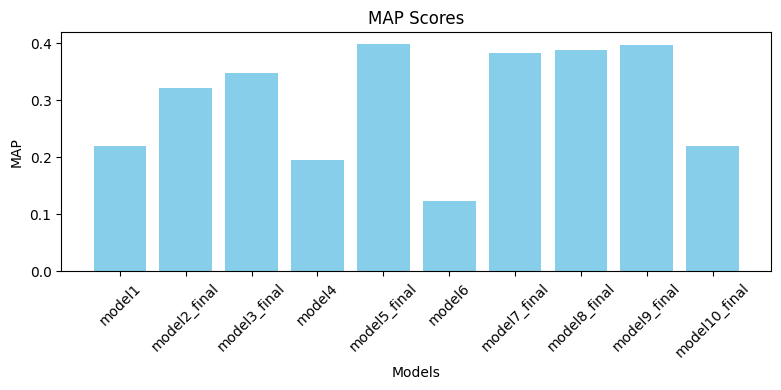

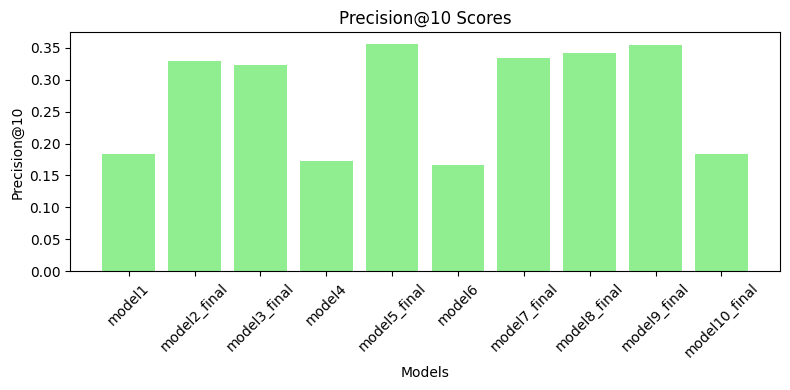

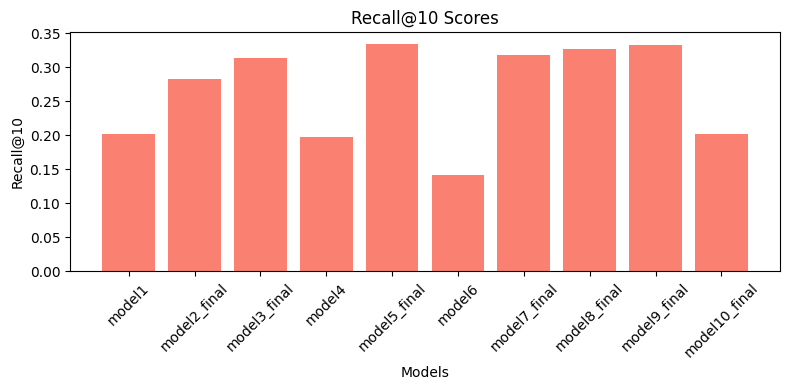

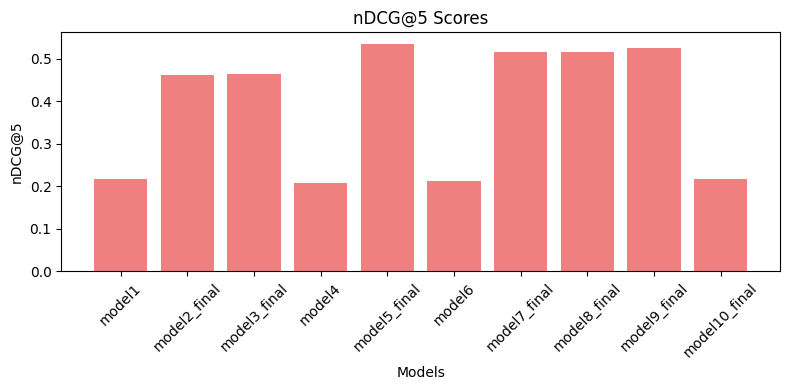

In [18]:
import matplotlib.pyplot as plt

models = list(evaluation_results_dict.keys())
map_scores = [evaluation_results_dict[model]['MAP'] for model in models]
precision_scores = [evaluation_results_dict[model]['Precision@10'] for model in models]
recall_scores = [evaluation_results_dict[model]['Recall@10'] for model in models]
ndcg_scores = [evaluation_results_dict[model]['nDCG@5'] for model in models]


plt.figure(figsize=(8, 4))
plt.bar(models, map_scores, color='skyblue')
plt.title('MAP Scores')
plt.xlabel('Models')
plt.ylabel('MAP')
plt.xticks(rotation=45)  
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(models, precision_scores, color='lightgreen')
plt.title('Precision@10 Scores')
plt.xlabel('Models')
plt.ylabel('Precision@10')
plt.xticks(rotation=45)  
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(models, recall_scores, color='salmon')
plt.title('Recall@10 Scores')
plt.xlabel('Models')
plt.ylabel('Recall@10')
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(models, ndcg_scores, color='lightcoral')
plt.title('nDCG@5 Scores')
plt.xlabel('Models')
plt.ylabel('nDCG@5')
plt.xticks(rotation=45)  
plt.tight_layout()
plt.show()


<div style="direction: rtl; text-align: right;">
    این کد با استفاده از کتابخانه‌ی matplotlib، چهار نمودار میله‌ای از نتایج ارزیابی مدل‌ها (در قالب MAP، Precision@10، Recall@10 و nDCG@5) رسم می‌کند. عملکرد کد به شرح زیر است:
    <br><br>
    مدل‌ها به‌عنوان کلیدهای دیکشنری در لیستی به نام models ذخیره می‌شوند. مقادیر مربوط به هر معیار ارزیابی (مانند MAP) نیز در لیست‌های مجزایی مانند map_scores، precision_scores، recall_scores و ndcg_scores قرار می‌گیرند.
    <br><br>
    کد برای هر یک از معیارهای ارزیابی (MAP، Precision@10، Recall@10 و nDCG@5) یک نمودار میله‌ای جداگانه.
    <br><br>
    -----------------------------
    <br><br>
    تحلیل نمودار ها
    <br><br>
    1. MAP: این معیار به طور خاص برای ارزیابی عملکرد مدل‌هایی که برای بازیابی مستندات مرتبط با پرس‌وجوها به کار می‌روند، مفید است. همانطور که در نمودار مشخص است این معیار برای مدل های ۵ و ۹ بیشترین مقدار را داشته و برای مدل های ۶ و ۴ کمترین مقدار را داشته است. این نشاندهنده آن است میانگین دقت متوسط برای مدل های ۵ و ۹ بهتر از بقیه مدل ها بوده است.
    <br><br>
    2. Precision@10: این معیار نشان دهنده این است که در ۱۰ سند اول، به چه نسبتی سند مرتبط وجود دارد. این معیار هم برای مدل ۵ و ۹ بیشترین مقدار را داشته است و برای مدل های ۴ و ۶ کمترین مقدار را داشته است که نشان دهنده این است در مدل های ۵ و ۹ بیشترین سند مرتبط در ۱۰ سند اول منتشر شده نسبت به بقیه مدل ها وجود داشته است و در سند ۴ و ۶ سندهای نامرتبط بیشتری نمایش داده شده.
    <br><br>
    3, Recall@10: این معیار نشان دهنده آن است که در ۱۰ سند اول چه نسبتی از سند های مرتبط نشان داده شده است. در این نمودار هم مدل ۵ و ۹ بیشترین مقدار فراخوانی را دارند که نشان میدهد این دو مدل بیشترین اسناد را از بین اسناد مرتبط در ۱۰ سند اول استخراج کرده اند. اما مدل ۴ که کمترین معیار را دارد تعداد کمی از کل سند های مرتبط را در ۱۰ سند اول خود بازیابی کرده است.
    <br><br>
    5. nDCG@5: این معیار کیفیت نتایج رتبه بندی را بررسی میکند و توجهش به میزان مرتبط بودن اسناد و ترتیب آنها در خروجی مدل است. بیانگر این است که مستندات مرتبط در رتبه‌های بالاتر ارزش بیشتری دارند، زیرا logarithmic discounting اعمال می‌شود. به عبارت دیگر، هر چه یک مستند مرتبط در رتبه بالاتری باشد، امتیاز بیشتری به دست می‌آورد. این معیار برای مدل های ۵ و ۹ بیشترین مقدار است که نشان میدهد این دو مدل سندهای مرتبط بیشتری را در ۵ خروجی اول خود داشتند و این سند های مرتبط در رتبه های بالای خروجی قرار داشتند همچنین مدل های ۴ و ۶ بدترین عملکرد را از نظر این معیار داشتند و نشان دهنده آن است که این دو مدل سندهای مرتبط کمتری را در رتبه های بالاتر خود نمایش می دهند.
    <br><br>
    طبق نتایج به دست آمده مدل های ۵ و ۹ بهترین عملکرد را از نظر همه معیارها داشته اند. همچنین مدل های ۴ و ۶ از نظر همه معیار ها بدترین عملکرد را داشته اند.
    <br><br>
    مدل ۱۰ همان مدل پیشنهادی است که مشاهده میشود عملکرد خوبی نداشته اما عملکرد آن بهتر از مدل های ۴ و ۶ است.
    فرمول ریاضی این مدل در فایل ورد نوشته میشود.
<div>

# **سوال دوم:**

In [19]:
#YOUR CODE HERE
import numpy as np

b_values_large = np.arange(0.0, 1.1, 0.5)  
best_map_large_model11 = 0
best_map_large_model12 = 0
best_params_large_model11 = 0
best_params_large_model12 = 0

for b in b_values_large:
    print(f"Evaluating model11 and model12 with b={b}")
    params = {'b': b}
    
    evaluation_results_model11 = ev.evaluate_scoring_method(inverted_index, rm.model11, queries, relevance_judgments, params=params)
    current_map_model11 = evaluation_results_model11['MAP']
    print(f"MAP for model11 (b={b}): {current_map_model11}")
    
    if current_map_model11 > best_map_large_model11:
        best_map_large_model11 = current_map_model11
        best_params_large_model11 = b
        
    evaluation_results_model12 = ev.evaluate_scoring_method(inverted_index, rm.model12, queries, relevance_judgments, params=params)
    current_map_model12 = evaluation_results_model12['MAP']
    print(f"MAP for model12 (b={b}): {current_map_model12}")
    
    if current_map_model12 > best_map_large_model12:
        best_map_large_model12 = current_map_model12
        best_params_large_model12 = b

print(f"\nBest MAP with large steps for model11: {best_map_large_model11} with b={best_params_large_model11}")
print(f"Best MAP with large steps for model12: {best_map_large_model12} with b={best_params_large_model12}")
#with small steps
b_start_model11 = best_params_large_model11
b_start_model12 = best_params_large_model12

b_values_small_model11 = np.arange(b_start_model11 - 0.2, b_start_model11 + 0.3, 0.05)  # گام‌های کوچک برای b در model11
b_values_small_model12 = np.arange(b_start_model12 - 0.2, b_start_model12 + 0.3, 0.05)  # گام‌های کوچک برای b در model12

best_map_small_model11 = 0
best_map_small_model12 = 0
best_params_small_model11 = 0
best_params_small_model12 = 0

for b_model11, b_model12 in zip(b_values_small_model11, b_values_small_model12):
    print(f"Evaluating model11 with small b={b_model11} and model12 with small b={b_model12}")
    
    params_model11 = {'b': b_model11}
    evaluation_results_model11 = ev.evaluate_scoring_method(inverted_index, rm.model11, queries, relevance_judgments, params=params_model11)
    current_map_model11 = evaluation_results_model11['MAP']
    print(f"MAP for model11 (b={b_model11}): {current_map_model11}")
    
    if current_map_model11 > best_map_small_model11:
        best_map_small_model11 = current_map_model11
        best_params_small_model11 = b_model11

    params_model12 = {'b': b_model12}
    evaluation_results_model12 = ev.evaluate_scoring_method(inverted_index, rm.model12, queries, relevance_judgments, params=params_model12)
    current_map_model12 = evaluation_results_model12['MAP']
    print(f"MAP for model12 (b={b_model12}): {current_map_model12}")
    
    if current_map_model12 > best_map_small_model12:
        best_map_small_model12 = current_map_model12
        best_params_small_model12 = b_model12
#model 11
print(f"\nBest MAP with small steps for model11: {best_map_small_model11} with b={best_params_small_model11}")
print(f"Best MAP with small steps for model12: {best_map_small_model12} with b={best_params_small_model12}")
params = {'b': best_params_small_model11}
evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.model11, queries, relevance_judgments, params=params)
evaluation_results_dict['model11'] = evaluation_results
print("evaluation results for model11:",evaluation_results)
print(f"MAP for model11 (b={0.75}): {evaluation_results['MAP']}")
#model 12
params = {'b': best_params_small_model12}
evaluation_results = ev.evaluate_scoring_method(inverted_index, rm.model12, queries, relevance_judgments, params=params)
evaluation_results_dict['model12'] = evaluation_results
print("evaluation results for model12:",evaluation_results)
print(f"MAP for model12 (b={0.75}): {evaluation_results['MAP']}")


Evaluating model11 and model12 with b=0.0
MAP for model11 (b=0.0): 0.3428
MAP for model12 (b=0.0): 0.2993
Evaluating model11 and model12 with b=0.5
MAP for model11 (b=0.5): 0.2813
MAP for model12 (b=0.5): 0.293
Evaluating model11 and model12 with b=1.0
MAP for model11 (b=1.0): 0.0539
MAP for model12 (b=1.0): 0.0763

Best MAP with large steps for model11: 0.3428 with b=0.0
Best MAP with large steps for model12: 0.2993 with b=0.0
Evaluating model11 with small b=-0.2 and model12 with small b=-0.2
MAP for model11 (b=-0.2): 0.0538
MAP for model12 (b=-0.2): 0.0582
Evaluating model11 with small b=-0.15000000000000002 and model12 with small b=-0.15000000000000002
MAP for model11 (b=-0.15000000000000002): 0.0726
MAP for model12 (b=-0.15000000000000002): 0.0763
Evaluating model11 with small b=-0.10000000000000003 and model12 with small b=-0.10000000000000003
MAP for model11 (b=-0.10000000000000003): 0.1051
MAP for model12 (b=-0.10000000000000003): 0.1063
Evaluating model11 with small b=-0.050000

<div style="direction: rtl; text-align: right;">
    الف:
    <br><br>
    در ابتدا، مقادیر اولیه پارامتر b بین بازه 0.0 تا 1.0 با گام‌های بزرگ (0.5) تعریف می‌شود. این مقدار پارامتر کنترل می‌کند که تا چه حد طول سند بر امتیاز نهایی سند تاثیر بگذارد.
    <br><br>
    برای هر مقدار b در بازه تعریف‌شده، دو مدل model11 و model12 مورد ارزیابی قرار می‌گیرند. ارزیابی به وسیله evaluate_scoring_method انجام می‌شود که با توجه به شاخص  inverted index، queries، relevance judgments عمل می‌کند.
    <br><br>
    پس از بررسی مقادیر b با گام‌های بزرگ، بهترین مقدار b برای هر دو مدل (که بالاترین MAP را دارد) به عنوان نقطه شروع برای مراحل بعدی انتخاب می‌شود.
    <br><br>
    در این مرحله، پارامتر b با گام‌های کوچک‌تری در اطراف مقادیر بهینه انتخاب شده از مرحله قبلی تنظیم می‌شود (گام‌های 0.05 در بازه‌هایی که حول مقدار بهینه اولیه b قرار دارند).
    مشابه مرحله قبل، مدل‌ها ارزیابی می‌شوند و بهترین مقدار MAP و پارامتر b با دقت بیشتری محاسبه و ذخیره می‌شود.
    <br><br>
    در نهایت، بهترین مقدار b و MAP برای هر دو مدل با گام‌های کوچک چاپ می‌شود.
    <br><br>
    مقدار بهینه b برای هر دو مدل عدد 0.75 شده است و با این مقدار مدل اصلی دارای مولفه های تودرتو بهترین عملکرد را دارد این معیار ها نشان میدهد مدل اصلی بیشترین نسبت استخراج سند های مرتبط، بیشترین نمایش سندهای مرتبط و نمایش سندهای مرتبط در بالاترین رتبه های نمایش داده شده را دارد.
    <br><br>
    --------------------------------------------------
    <br><br>
    ب:
    <br><br>
    نتایج مدل BM25:
    <br>
    {'MAP': 0.3672, 'Precision@10': 0.338, 'Recall@10': 0.3102, 'nDCG@5': 0.5081}
    <br><br>
    نتایج مدل BM25+:
    <br>
    {MAP: 0.3971, Precision@10: 0.354, Recall@10: 0.3326, nDCG@5: 0.5257}
    <br><br>
    نتایج مدل اصلی این سوال:
    <br>
    {'MAP': 0.3926, 'Precision@10': 0.348, 'Recall@10': 0.3178, 'nDCG@5': 0.5367}
    <br><br>
    همانطور که مشخص است مقدار MAP برای مدل اصلی این سوال بیشتر از دو مدل دیگر است که نشان دهنده آن است میانگین دقت متوسط استخراج سندها در این مدل بهتر بوده است.
    <br><br>
    معیار Precision@10 نیز برای مدل اصلی بهتر از دو مدل دیگر بوده و نشان میدهد از بین ۱۰ سند اول استخراج شده این مدل بیشترین سند مرتبط را دارا بوده است.
    <br><br>
    معیار Recall@10 هم برای این مدل بیشتر از دو مدل دیگر بوده که نشان دهنده آن است در بین ۱۰ سند استخراج شده اول مدل اصلی این قسمت بیشترین نسبت استخراج سند های مرتبط را داشته است.
    <br><br>
    معیار nDCG@5 نیز در این مدل بیشتر از دو مدل دیگر است که این بدان معناست که در بین ۵ سند اول منتشر شده توسط این مدل بیشترین تعداد سند مرتبط در رتبه های بالاتر قرار داشته.
    <br><br>
    همانطور که در بالا دیدیم مدل اصلی بهترین عملکرد را در بین این سه مدل داشته است و برداشت من این است دلیل این موضوع وجود پارامتر M است که تعداد کل مستندات موجود در ایندکس معکوس می باشد.
<div>

# **نکات مهم**

<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
    <p><strong>مهلت تحویل بدون جریمه:</strong> ۱۵ مهر ۱۴۰۲</p>
    <p><strong>مهلت تحویل با تاخیر (با جریمه):</strong> ۲۲ مهر ۱۴۰۲</p>
</div>
<h4 dir="rtl" style="font-family: Vazir; width: 85%;">فایل ارسالی شما باید با فرمت زیر نامگذاری شود: <code>IIR_CA1_STUDENTID.ipynb</code></h4>

<h4 dir="rtl" style="font-family: Vazir; width: 85%;">نحوه انجام این تمرین:</h4>
<ul dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;"> <li>برخی سوالات نیاز به نوشتن کد پایتون و محاسبه نتایج دارند کدها بایستی طبق فایل تمرین به طور کامل نوشته شوند.</li> <li> کدها و تفسیرهای هربخش را به طور مشخص در همین نوت‌بوک بنویسید. سعی کنید هربخش به طور مشخصی جداشده باشد و ساختار نوت‌بوک خوانا باشد.</li>  </ul>

<h4 dir="rtl" style="font-family: Vazir; width: 85%;">صداقت علمی:</h4> <ul dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;"> <li>ما نوت‌بوک‌های تعداد مشخصی از دانشجویان که به صورت تصادفی انتخاب می‌شوند، بررسی خواهیم کرد. این بررسی‌ها اطمینان حاصل می‌کنند که کدی که نوشتید واقعاً پاسخ‌های موجود در نوت‌بوک شما را تولید می‌کند. اگر پاسخ‌های صحیح را در نوت‌بوک خود بدون کدی که واقعاً آن پاسخ‌ها را تولید کند تحویل دهید، این یک مورد جدی از عدم صداقت علمی محسوب می‌شود.</li> <li>ما همچنین بررسی‌های خودکاری را برای تشخیص سرقت علمی در نوت‌بوک‌های کولب انجام خواهیم داد. کپی کردن کد از دیگران نیز یک مورد جدی از عدم صداقت علمی محسوب می‌شود.</li> </ul>

<h4 dir="rtl" style="font-family: Vazir; width: 85%;">توضیحات تکمیلی:</h4> <ul dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<li>
خوانایی و دقت بررسی‌ها در گزارش نهایی از اهمیت ویژه‌ای برخوردار است. به تمرین‌هایی که به صورت کاغذی تحویل داده شوند یا به صورت عکس در سایت بارگذاری شوند، ترتیب اثری داده نخواهد شد.</li>
<li>
 همه‌ی کدهای پیوست گزارش بایستی قابلیت اجرای مجدد داشته باشند. در صورتی که برای اجرا مجدد آن‌ها نیاز به تنظیمات خاصی می‌باشد، بایستی تنظیمات مورد نیاز را نیز در گزارش خود ذکر کنید.  دقت کنید که  تمامی کدها باید توسط شما اجرا شده باشند و نتایج اجرا در فایل کدهای ارسالی مشخص باشد. به کدهایی که نتایج اجرای آن‌ها در فایل ارسالی مشخص نباشد نمره‌ای تعلق نمی‌گیرد.
</li>
<li>
تمرین تا یک هفته بعد از مهلت تعیین شده با تاخیر تحویل گرفته می‌شود. دقت کنید که شما جمعاً برای تمام تکالیف، ۱۴ روز زمان تحویل بدون جریمه دارید که تنها از ۷ روز آن برای هر تمرین می‌توانید استفاده کنید. در صورتی که این ۱۴ روز به اتمام رسیده باشد، به ازای هر روز تاخیر ده درصد جریمه می‌شود.
</li>
<li>توجه کنید این تمرین باید به صورت تک‌نفره انجام شود و پاسخ‌های ارائه شده باید نتیجه فعالیت فرد نویسنده باشد (همفکری و به اتفاق هم نوشتن تمرین نیز ممنوع است). در صورت مشاهده
 تشابه به همه افراد مشارکت‌کننده، نمره تمرین صفر و به استاد گزارش می‌گردد.
 </li>
 <li>برای مطالعه بیشتر درباره‌ی فرمت مارک‌دون می‌توانید از <a href="https://github.com/tajaddini/Persian-Markdown/blob/master/learn-MD.md">این لینک</a> مطالعه کنید.
 </li>

 </ul>
 </div>